In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"D:\Study\Degree\Y2S1\DS\taiwanese+bankruptcy+prediction\data.csv")

In [3]:
data.shape

(6819, 96)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
data.head(7)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
5,1,0.388680,0.415177,0.419134,0.590171,0.590251,0.998758,0.796903,0.808771,0.303116,...,0.710420,0.005278,0.622605,0.590172,0.829939,0.285087,0.026675,0.564538,1,0.019534
6,0,0.390923,0.445704,0.436158,0.619950,0.619950,0.998993,0.797012,0.808960,0.302814,...,0.736619,0.018372,0.623655,0.619949,0.829980,0.292504,0.026622,0.564200,1,0.015663


In [6]:
data.isna().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [7]:
data.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

<Axes: xlabel='Bankrupt?', ylabel='count'>

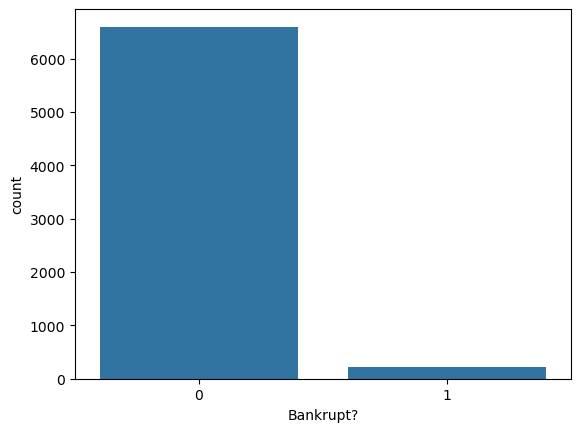

In [8]:
import seaborn as sns
sns.countplot(x ='Bankrupt?', data = data)

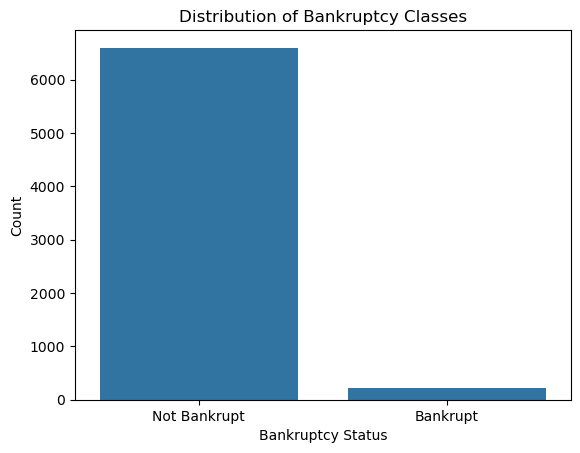

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Bankrupt?', data=data)
plt.title('Distribution of Bankruptcy Classes')
plt.xticks([0, 1], ['Not Bankrupt', 'Bankrupt'])
plt.xlabel('Bankruptcy Status')
plt.ylabel('Count')
plt.show()

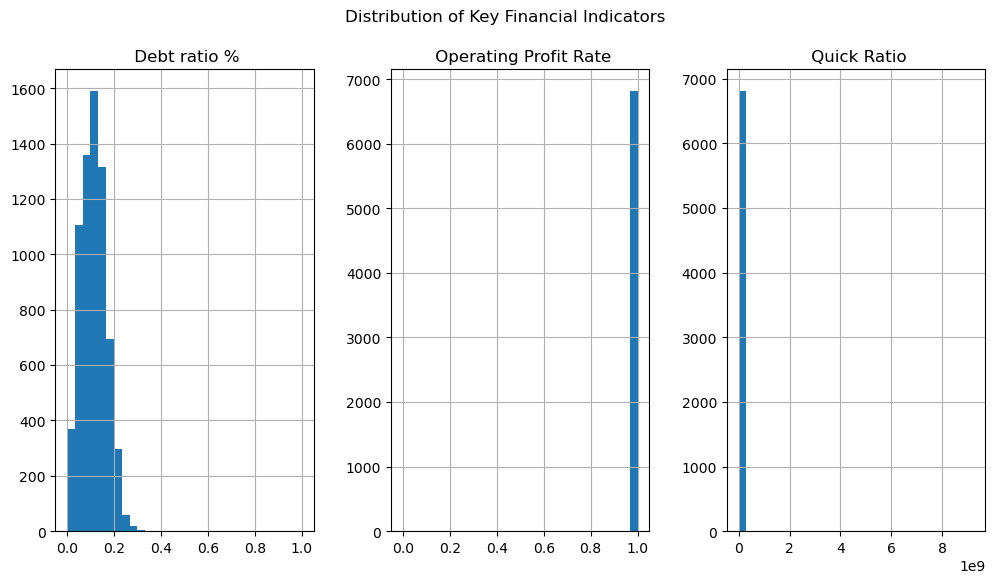

In [10]:
selected_features = [' Debt ratio %', ' Operating Profit Rate', ' Quick Ratio']
data[selected_features] = data[selected_features].apply(lambda x: x.str.strip() if x.dtype == "object" else x)

data[selected_features].hist(bins=30, figsize=(12, 6), layout=(1, 3))
plt.suptitle("Distribution of Key Financial Indicators")
plt.show()


<Axes: xlabel=' Debt ratio %', ylabel='count'>

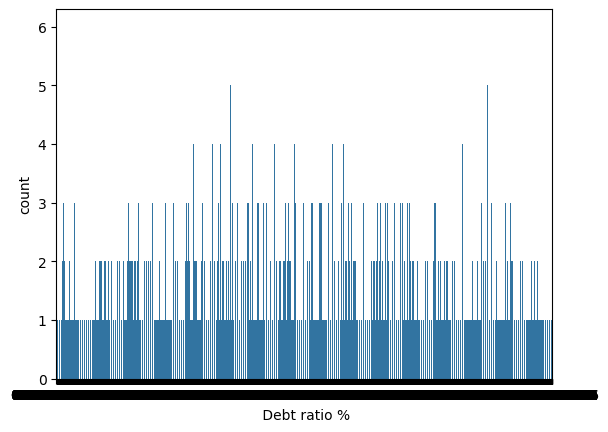

In [11]:
sns.countplot(x =' Debt ratio %', data = data)

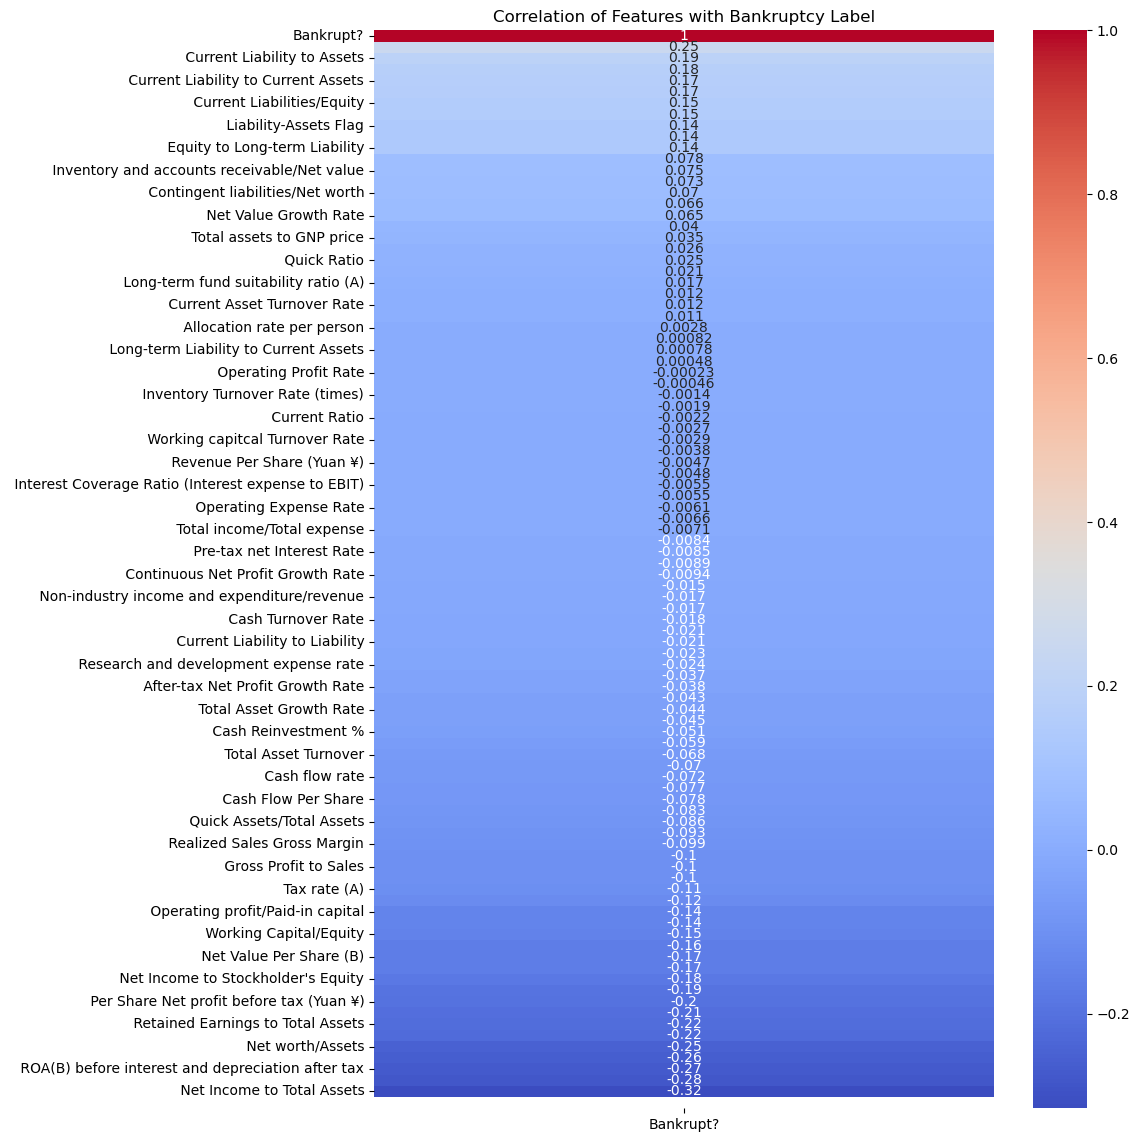

In [12]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 14))
sns.heatmap(corr[['Bankrupt?']].sort_values(by='Bankrupt?', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Bankruptcy Label")
plt.show()

In [8]:
data.columns = data.columns.str.strip()

In [9]:
X = data.drop(columns='Bankrupt?')
y = data['Bankrupt?']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [13]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [19]:
#KNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define parameter grid
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # p=1: Manhattan, p=2: Euclidean
}

knn_clf = KNeighborsClassifier()

grid_search_knn = GridSearchCV(knn_clf, param_grid_knn, cv=5, n_jobs=-1, verbose=3)

# Fit on balanced training data
grid_search_knn.fit(X_train_bal, y_train_bal)

print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best cross-validation score for KNN:", grid_search_knn.best_score_)


Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best parameters for KNN: {'algorithm': 'auto', 'n_neighbors': 2, 'p': 1, 'weights': 'uniform'}
Best cross-validation score for KNN: 0.97434514141336


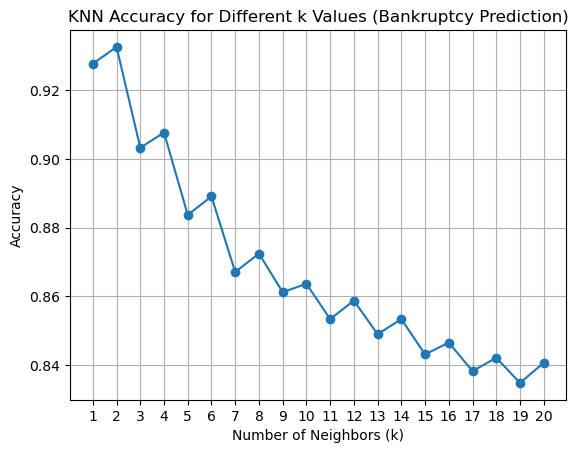

In [15]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
k_range = range(1, 21)  # Testing k values from 1 to 20
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)  # Train the model with the current k
    knn_pred = knn.predict(X_test_scaled)  # Predict on the test set
    score = accuracy_score(y_test, knn_pred)  # Compute accuracy
    k_scores.append(score)

plt.plot(k_range, k_scores, marker='o')
plt.title('KNN Accuracy for Different k Values (Bankruptcy Prediction)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_range)
plt.show()

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Use the balanced training set (after SMOTE)
knn_model = KNeighborsClassifier(n_neighbors=2, weights="uniform", p=1, algorithm="auto")  # use best k found from GridSearchCV
knn_model.fit(X_train_bal, y_train_bal)

# Predict on the original scaled test set (no SMOTE!)
knn_test_pred = knn_model.predict(X_test_scaled)

# Predict on balanced training set (for reference)
knn_train_pred = knn_model.predict(X_train_bal)

# Accuracy scores
print("KNN training accuracy:", accuracy_score(y_train_bal, knn_train_pred))
print("KNN testing accuracy:", accuracy_score(y_test, knn_test_pred))

KNN training accuracy: 1.0
KNN testing accuracy: 0.9379276637341154


Classification Report (KNN on Test Set):

              precision    recall  f1-score   support

Not Bankrupt       0.98      0.95      0.97      1980
    Bankrupt       0.26      0.48      0.34        66

    accuracy                           0.94      2046
   macro avg       0.62      0.72      0.65      2046
weighted avg       0.96      0.94      0.95      2046

KNN Test Accuracy: 0.9379276637341154


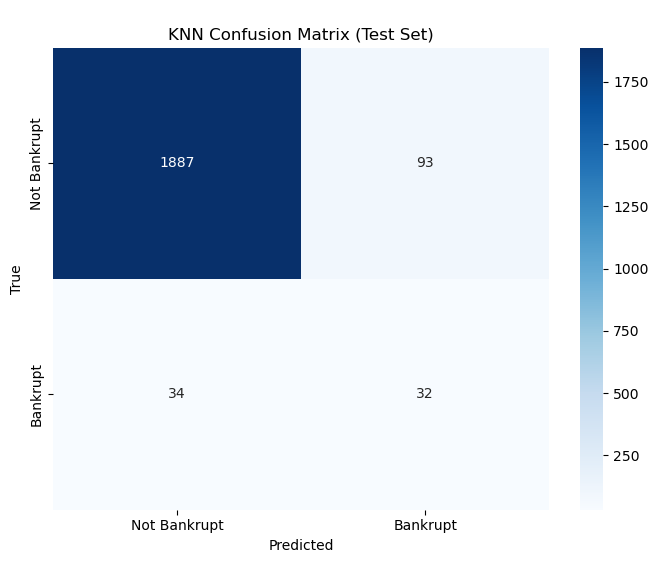

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the scaled test set
knn_test_pred = knn_model.predict(X_test_scaled)

# Classification Report for KNN
print("Classification Report (KNN on Test Set):\n")
print(classification_report(y_test, knn_test_pred, target_names=['Not Bankrupt', 'Bankrupt']))

# Accuracy
print("KNN Test Accuracy:", accuracy_score(y_test, knn_test_pred))

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, knn_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title('\nKNN Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

KNN AUC Score: 0.8308


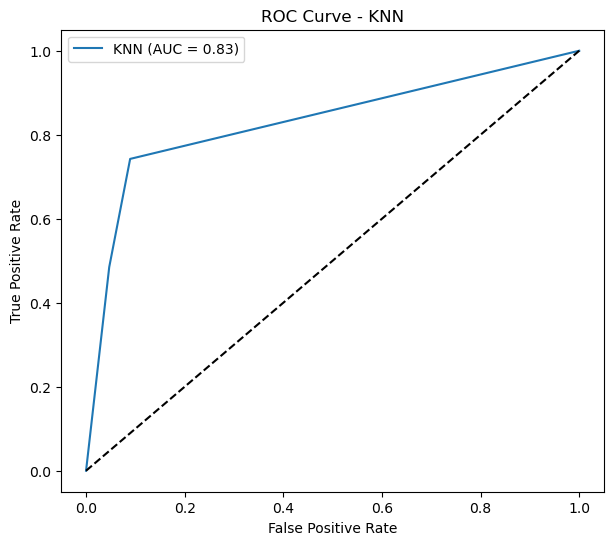

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (bankrupt = 1)
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Calculate AUC score
auc_score_knn = roc_auc_score(y_test, y_proba_knn)
print(f"KNN AUC Score: {auc_score_knn:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_knn)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc_score_knn:.2f})')
plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()


In [25]:
# Logistic Regression (LR)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lr_balanced = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid,
    refit=True,
    verbose=0 
)

grid_lr_balanced.fit(X_train_bal, y_train_bal)
print("Best parameters found: ", grid_lr_balanced.best_params_)
print("Best CV score:", grid_lr_balanced.best_score_)

Best parameters found:  {'C': 100}
Best CV score: 0.9102632208073465


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train_pred = grid_lr_balanced.predict(X_train_bal)
trainAcc = accuracy_score(y_train_bal, y_train_pred)
print(f"\nLR Training accuracy: {trainAcc}")

# Make predictions on the test data
y_test_pred_lr = grid_lr_balanced.predict(X_test_scaled)
print("\nClassification Report (LR) : \n")
print(classification_report(y_test, y_test_pred_lr))
print(f"\nLR Test accuracy: {accuracy_score(y_test, y_test_pred_lr)}")


LR Training accuracy: 0.9125351807750596

Classification Report (LR) : 

              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1980
           1       0.18      0.71      0.29        66

    accuracy                           0.89      2046
   macro avg       0.59      0.80      0.62      2046
weighted avg       0.96      0.89      0.92      2046


LR Test accuracy: 0.8880742913000977


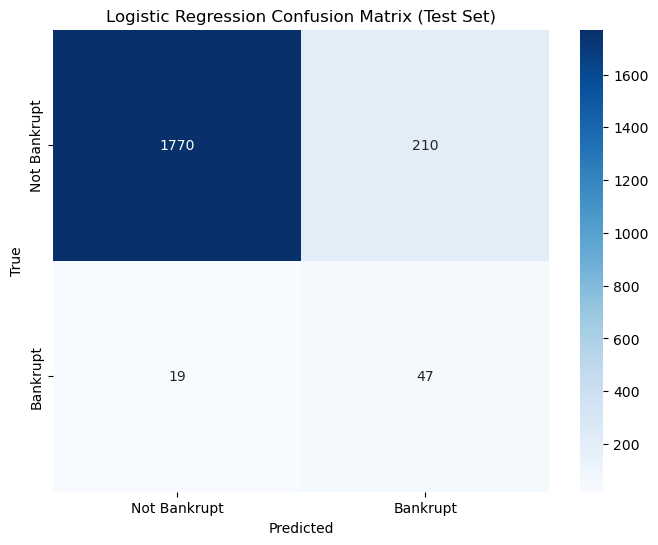

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title('Logistic Regression Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

AUC Score: 0.8893


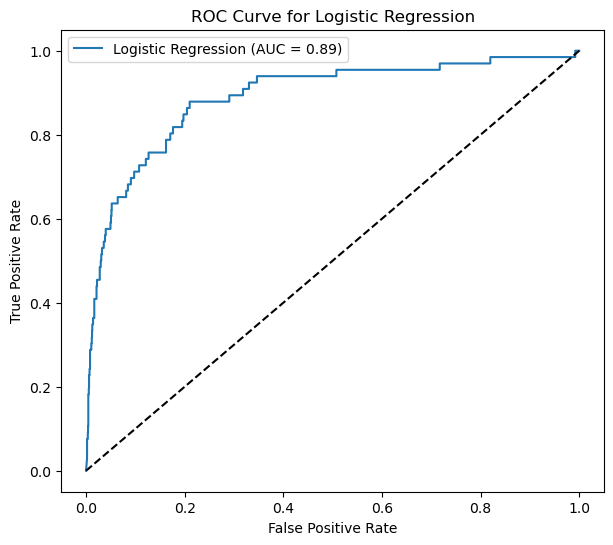

In [29]:
# AUC Score for LR
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get prediction probabilities for the positive class (1) from the test set
y_pred_proba = grid_lr_balanced.predict_proba(X_test_scaled)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed line for a random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

In [30]:
#ANN

In [31]:
!pip install tensorflow

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input

In [33]:
# Build the ANN model using an Input layer
ann_model = Sequential([
    Input(shape=(X_train_bal.shape[1],)), 
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') 
])

In [34]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           6,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,257 (32.25 KB)

 Trainable params: 8,257 (32.25 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Compile ANN
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit ANN on balanced training set
history = ann_model.fit(
    X_train_bal,
    y_train_bal,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

In [36]:
# Artificial Neural Network (ANN)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the scaled validation data
y_val_pred_ann_prob = ann_model.predict(X_val)
y_val_pred_ann = (y_val_pred_ann_prob > 0.5).astype(int) 

print("\nANN")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred_ann)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred_ann))

# Make predictions on the scaled test data
y_test_pred_ann_prob = ann_model.predict(X_test_scaled)
y_test_pred_ann = (y_test_pred_ann_prob > 0.5).astype(int)

print(f"\nTest accuracy: {accuracy_score(y_test, y_test_pred_ann)}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_ann))

train_accuracy_ann = history.history['accuracy'][-1]
print(f"\nTraining Accuracy: {train_accuracy_ann}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

ANN
Validation accuracy: 0.9759162303664921

Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       924
           1       0.57      1.00      0.73        31

    accuracy                           0.98       955
   macro avg       0.79      0.99      0.86       955
weighted avg       0.99      0.98      0.98       955

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step

Test accuracy: 0.9511241446725318

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1980
           1       0.33      0.48      0.39        66

    accuracy                           0.95      2046
   macro avg       0.65      0.73      0.68      2046
weighted avg       0.96      0.95      0.96      2046


Training Accuracy: 0.97975754737854


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


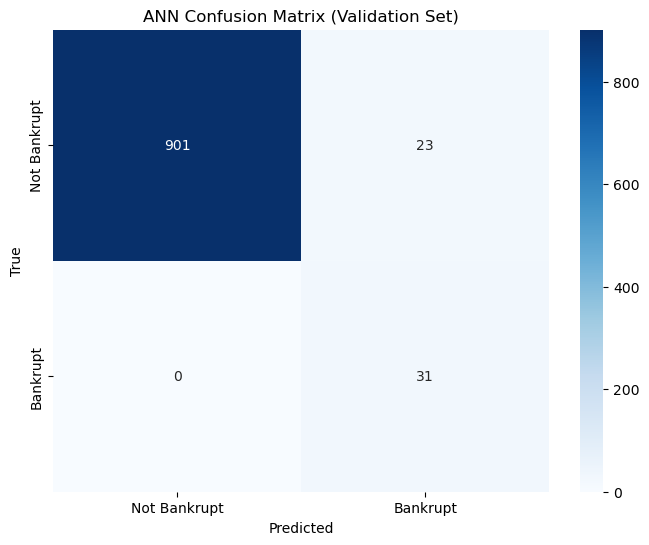

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation set
y_val_pred_ann_prob = ann_model.predict(X_val)
y_val_pred_ann = (y_val_pred_ann_prob > 0.5).astype(int)

# Confusion Matrix
cm_val_ann = confusion_matrix(y_val, y_val_pred_ann)

plt.figure(figsize=(8,6))
sns.heatmap(cm_val_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title('ANN Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step


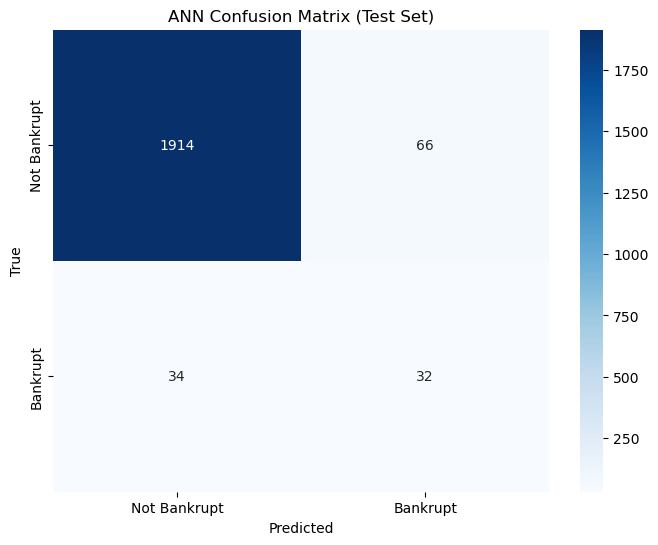

In [38]:
# Predict on test set
y_test_pred_ann_prob = ann_model.predict(X_test_scaled)
y_test_pred_ann = (y_test_pred_ann_prob > 0.5).astype(int)

# Confusion Matrix
cm_test_ann = confusion_matrix(y_test, y_test_pred_ann)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title('ANN Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


AUC Score: 0.8451


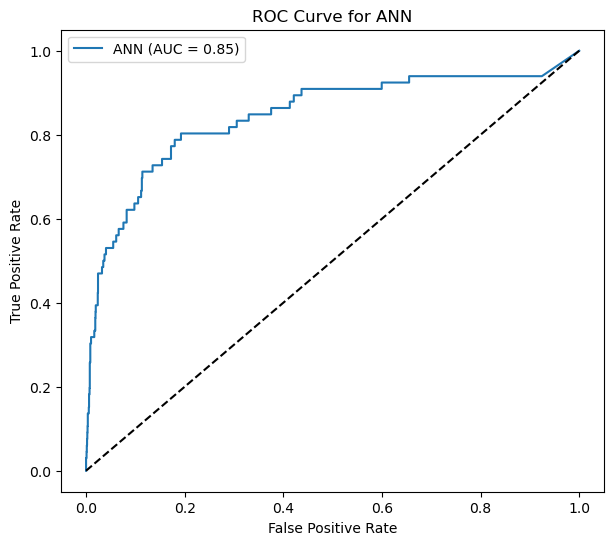

In [39]:
# AUC Score for ANN
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate the AUC score using the prediction probabilities
auc_score_ann = roc_auc_score(y_test, y_test_pred_ann_prob)
print(f"AUC Score: {auc_score_ann:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_ann_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc_score_ann:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ANN')
plt.legend()
plt.show()

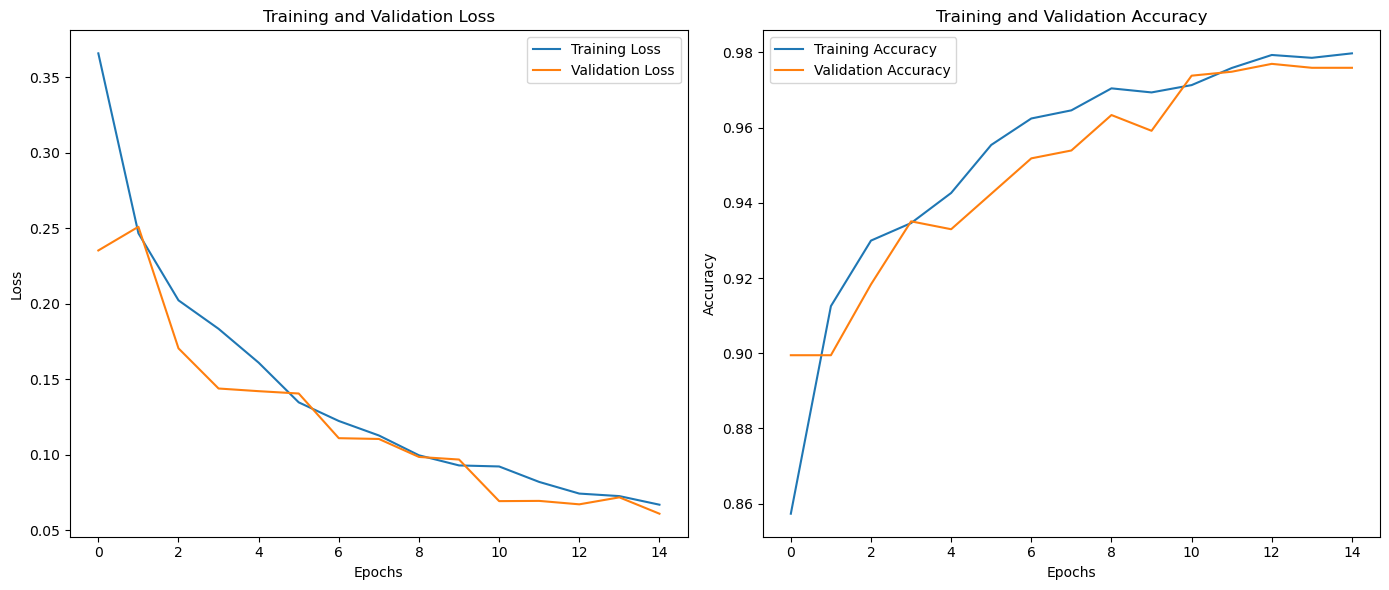

In [40]:
import matplotlib.pyplot as plt

# Plotting Training vs. Validation Loss and Accuracy
plt.figure(figsize=(14, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
#SVM

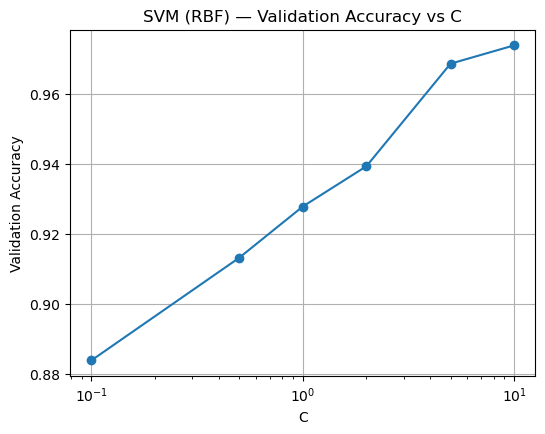

Best C (manual): 10.0 | Best Val Accuracy: 0.9738


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)


Cs = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
val_scores = []

for c in Cs:
    model = SVC(C=c, kernel='rbf', gamma='scale', probability=True,
                class_weight='balanced', random_state=42)
    # Train on SMOTE-balanced (already scaled) training data
    model.fit(X_train_bal, y_train_bal)
    # Validate on the held-out validation split (scaled)
    y_val_pred_tmp = model.predict(X_val)
    val_scores.append(accuracy_score(y_val, y_val_pred_tmp))

plt.figure(figsize=(6,4.5))
plt.plot(Cs, val_scores, marker='o')
plt.xscale('log')
plt.title('SVM (RBF) — Validation Accuracy vs C')
plt.xlabel('C'); plt.ylabel('Validation Accuracy'); plt.grid(True)
plt.show()

best_index = int(np.argmax(val_scores))
best_C = Cs[best_index]
print(f"Best C (manual): {best_C} | Best Val Accuracy: {val_scores[best_index]:.4f}")


In [43]:
param_grid = {
    "C": np.logspace(-2, 1, 10),   # 0.01 ... 10
    "gamma": ["scale", "auto"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

# Fit on SMOTE-balanced (scaled) training data
grid.fit(X_train_bal, y_train_bal)
print("Grid best params:", grid.best_params_)
print(f"Grid CV best AUC: {grid.best_score_:.4f}")

final_C     = grid.best_params_.get("C", best_C)
final_gamma = grid.best_params_.get("gamma", "scale")


Grid best params: {'C': np.float64(10.0), 'gamma': 'auto'}
Grid CV best AUC: 0.9947


In [44]:
svm_model = SVC(
    kernel='rbf',
    C=final_C,
    gamma=final_gamma,
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_bal, y_train_bal)

# Predictions
y_train_pred = svm_model.predict(X_train_bal)     # train (balanced, scaled)
y_test_pred_svm  = svm_model.predict(X_test_scaled)   # test (scaled)

# Accuracies
print(f"Training Accuracy:   {accuracy_score(y_train_bal, y_train_pred):.4f}")
print(f"Testing  Accuracy:   {accuracy_score(y_test,      y_test_pred_svm):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred_svm, digits=4,
                            target_names=['Not Bankrupt','Bankrupt']))


Training Accuracy:   0.9906
Testing  Accuracy:   0.9541

Test Classification Report:
              precision    recall  f1-score   support

Not Bankrupt     0.9801    0.9722    0.9762      1980
    Bankrupt     0.3293    0.4091    0.3649        66

    accuracy                         0.9541      2046
   macro avg     0.6547    0.6907    0.6705      2046
weighted avg     0.9591    0.9541    0.9564      2046



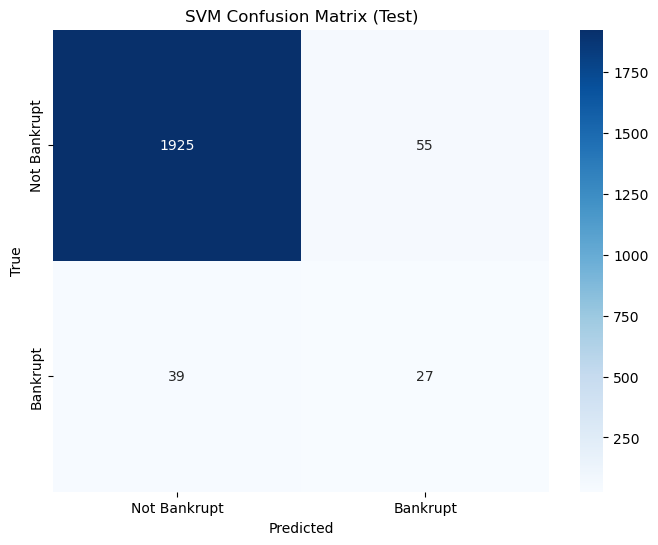

In [45]:
cm_test = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title('SVM Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

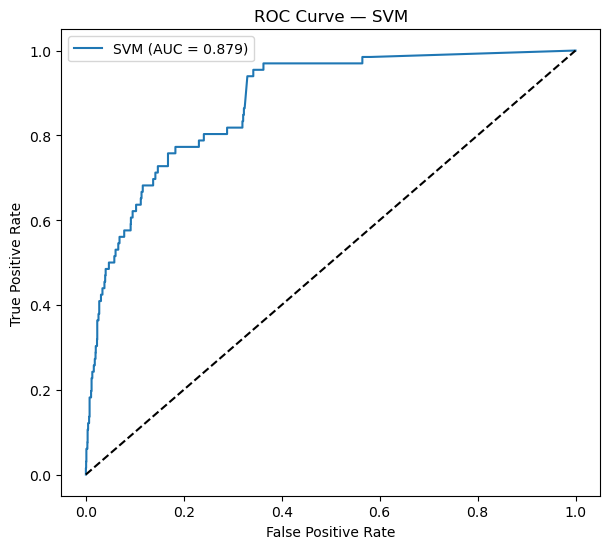

Test AUC: 0.8790


In [46]:
y_proba_test = svm_model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba_test)
fpr, tpr, _ = roc_curve(y_test, y_proba_test)

plt.figure(figsize=(6.2, 5.6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Test AUC: {auc:.4f}")


In [47]:
import matplotlib.pyplot as plt

# Results from your table (replace with exact values if needed)
models = ['KNN', 'LR', 'ANN', 'SVM']
accuracy = [0.896, 0.890, 0.9506, 0.9022]
recall_bankrupt = [0.55, 0.73, 0.50, 0.59]
f1_bankrupt = [0.25, 0.30, 0.40, 0.28]

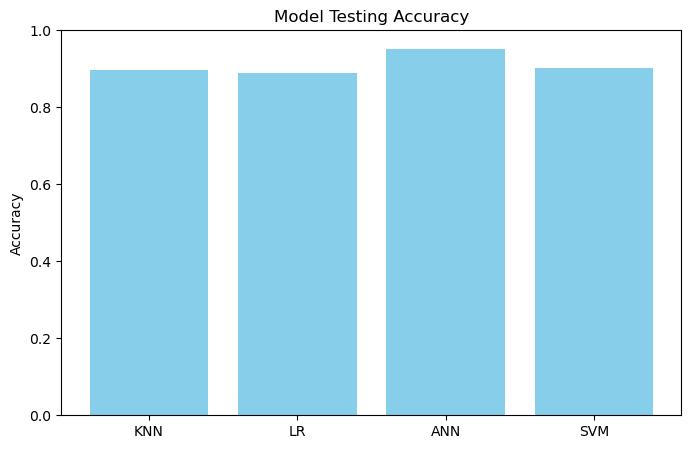

In [48]:
# Accuracy chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color='skyblue')
plt.ylim(0,1)
plt.title("Model Testing Accuracy")
plt.ylabel("Accuracy")
plt.show()

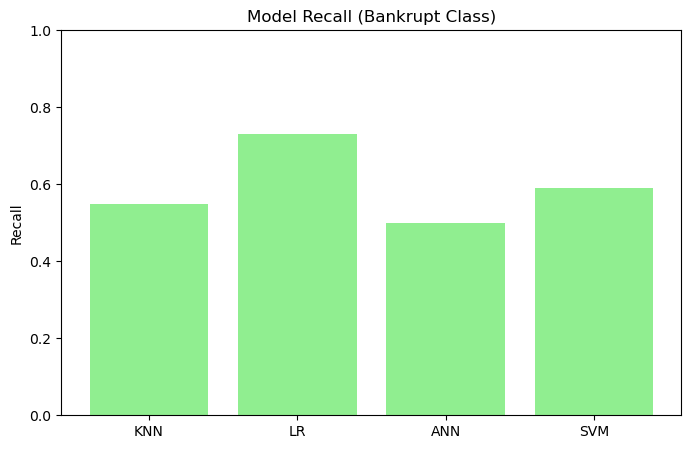

In [49]:
# Recall chart (Bankrupt class)
plt.figure(figsize=(8,5))
plt.bar(models, recall_bankrupt, color='lightgreen')
plt.ylim(0,1)
plt.title("Model Recall (Bankrupt Class)")
plt.ylabel("Recall")
plt.show()

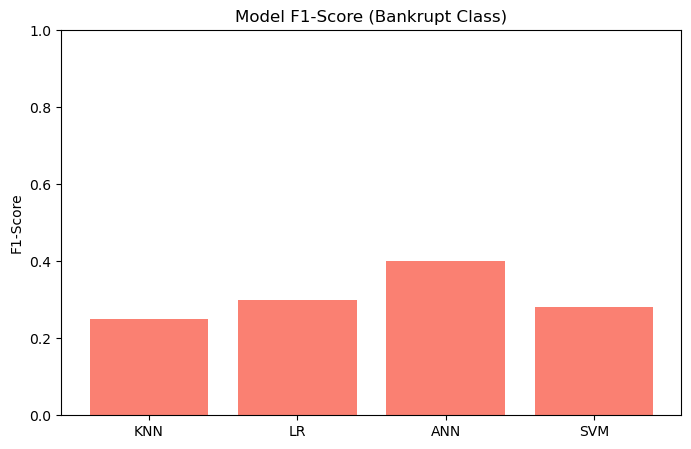

In [50]:
# F1-score chart (Bankrupt class)
plt.figure(figsize=(8,5))
plt.bar(models, f1_bankrupt, color='salmon')
plt.ylim(0,1)
plt.title("Model F1-Score (Bankrupt Class)")
plt.ylabel("F1-Score")
plt.show()

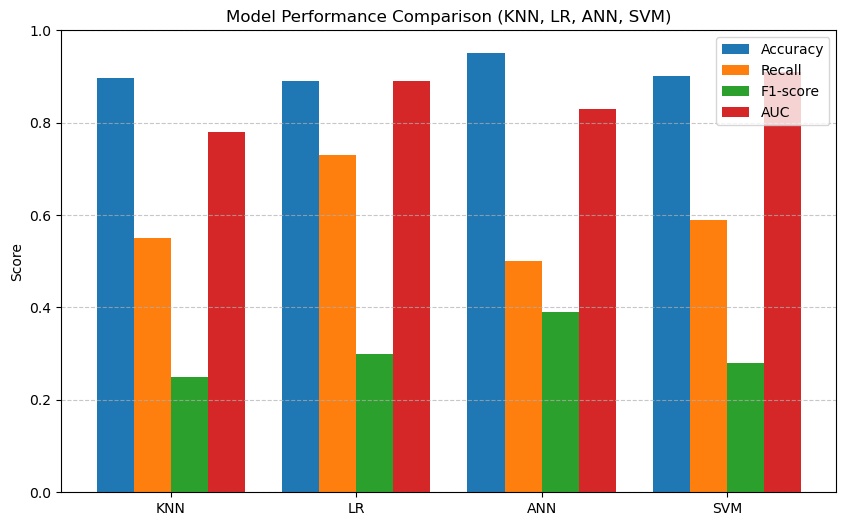

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Example metrics (replace with your actual results)
models = ['KNN', 'LR', 'ANN', 'SVM']
accuracy = [0.896, 0.890, 0.951, 0.902]
recall = [0.55, 0.73, 0.50, 0.59]
f1 = [0.25, 0.30, 0.39, 0.28]
auc = [0.78, 0.89, 0.83, 0.91]

x = np.arange(len(models))  # model positions
width = 0.2  # bar width

plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, recall, width, label='Recall')
plt.bar(x + 0.5*width, f1, width, label='F1-score')
plt.bar(x + 1.5*width, auc, width, label='AUC')

plt.xticks(x, models)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance Comparison (KNN, LR, ANN, SVM)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


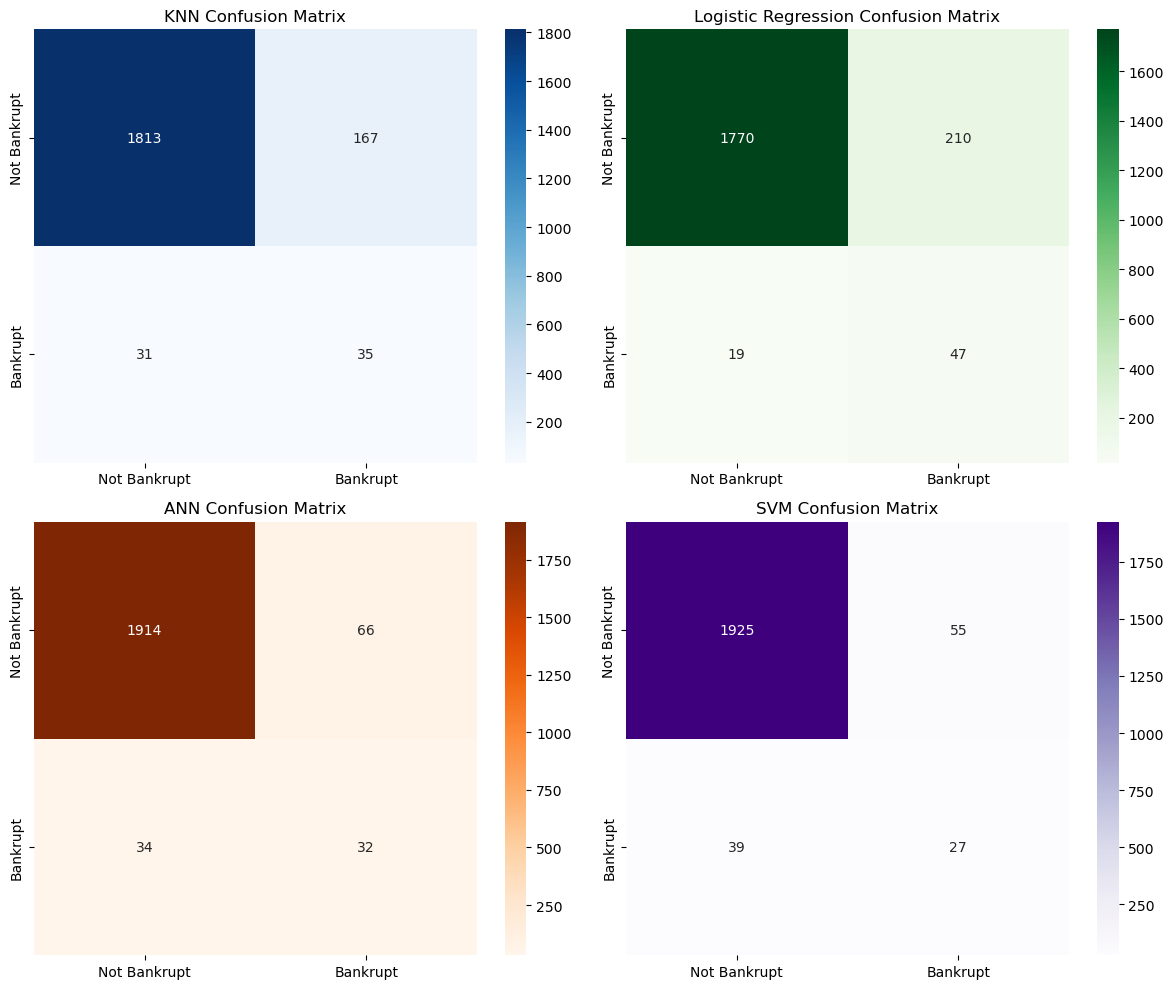

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrices for all models
cm_knn = confusion_matrix(y_test, knn_test_pred)
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
cm_ann = confusion_matrix(y_test, y_test_pred_ann)
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

# Plot them together
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Bankrupt','Bankrupt'],
            yticklabels=['Not Bankrupt','Bankrupt'])
axes[0,0].set_title("KNN Confusion Matrix")

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[0,1],
            xticklabels=['Not Bankrupt','Bankrupt'],
            yticklabels=['Not Bankrupt','Bankrupt'])
axes[0,1].set_title("Logistic Regression Confusion Matrix")

sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges', ax=axes[1,0],
            xticklabels=['Not Bankrupt','Bankrupt'],
            yticklabels=['Not Bankrupt','Bankrupt'])
axes[1,0].set_title("ANN Confusion Matrix")

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=axes[1,1],
            xticklabels=['Not Bankrupt','Bankrupt'],
            yticklabels=['Not Bankrupt','Bankrupt'])
axes[1,1].set_title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()


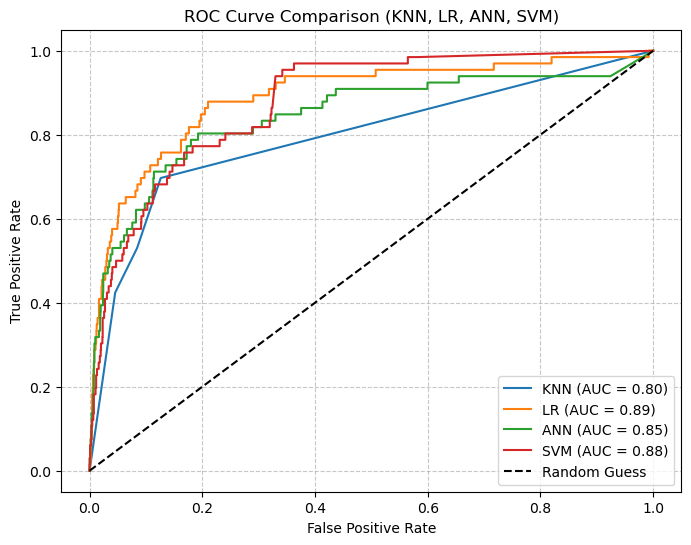

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
auc_lr = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.2f})")

# ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_test_pred_ann_prob)
auc_ann = roc_auc_score(y_test, y_test_pred_ann_prob)
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {auc_ann:.2f})")

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_test)
auc_svm = roc_auc_score(y_test, y_proba_test)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")

# Random baseline
plt.plot([0,1],[0,1],'k--', label="Random Guess")

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (KNN, LR, ANN, SVM)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


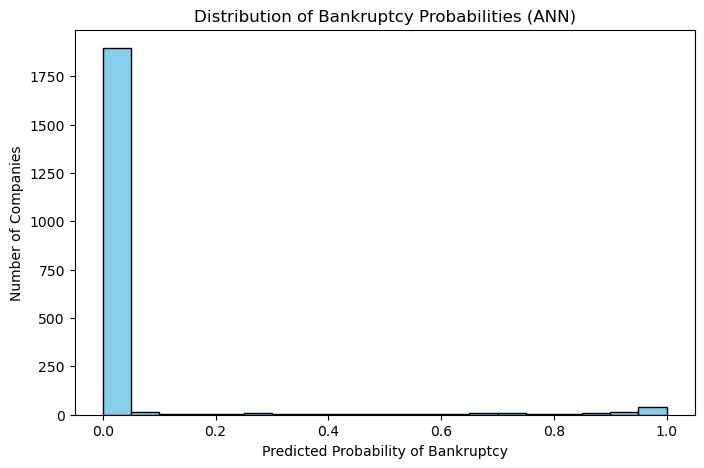

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_test_pred_ann_prob, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Bankruptcy Probabilities (ANN)")
plt.xlabel("Predicted Probability of Bankruptcy")
plt.ylabel("Number of Companies")
plt.show()


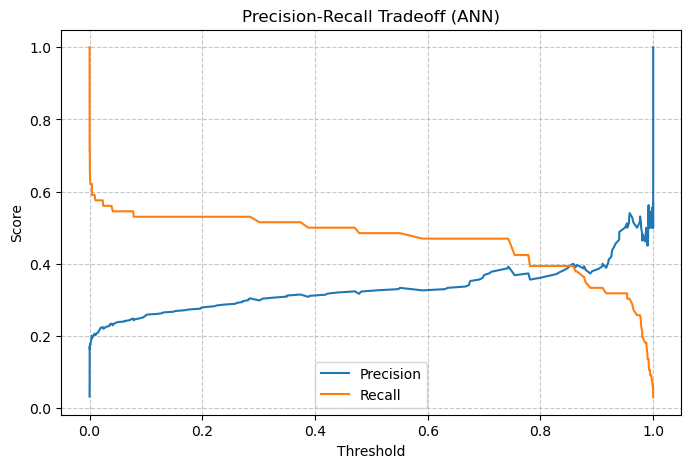

In [56]:
from sklearn.metrics import precision_recall_curve

prec, rec, thresh = precision_recall_curve(y_test, y_test_pred_ann_prob)

plt.figure(figsize=(8,5))
plt.plot(thresh, prec[:-1], label="Precision")
plt.plot(thresh, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff (ANN)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


C:\Users\johns\AppData\Local\Temp\ipykernel_19912\2098090148.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test_pred_ann.ravel(), palette="Set2")


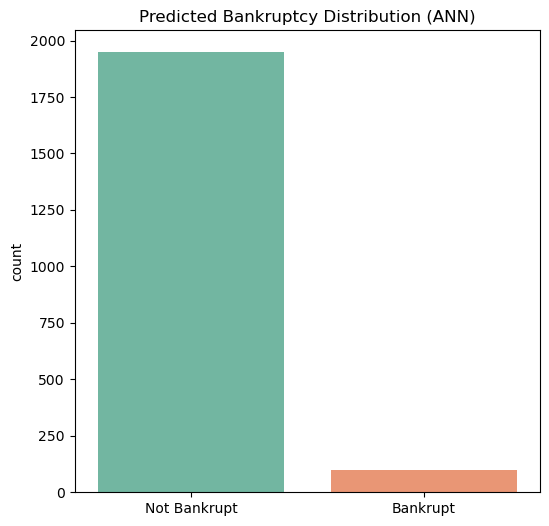

In [57]:
import seaborn as sns

plt.figure(figsize=(6,6))
sns.countplot(x=y_test_pred_ann.ravel(), palette="Set2")
plt.xticks([0,1], ["Not Bankrupt", "Bankrupt"])
plt.title("Predicted Bankruptcy Distribution (ANN)")
plt.show()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step
64/64 ━━━━━━━━━━━

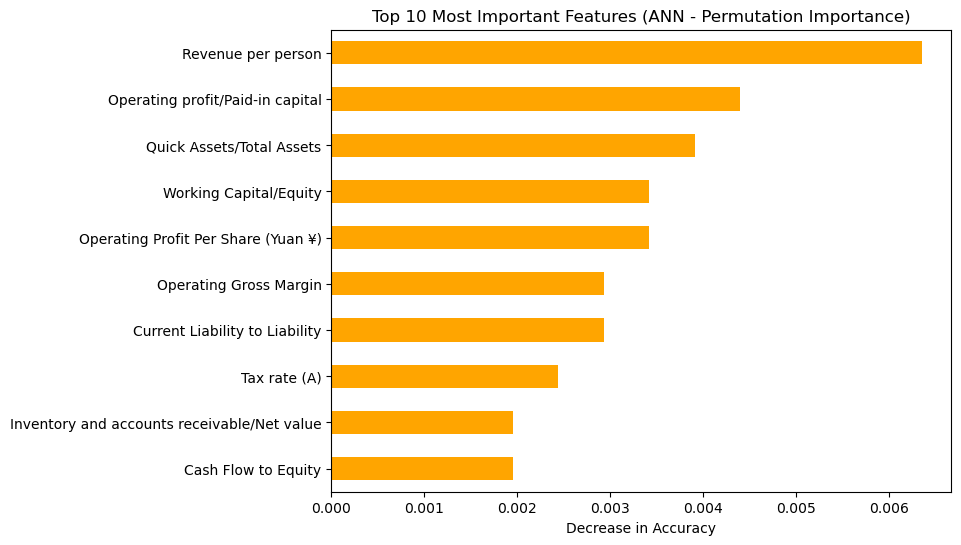

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Baseline accuracy
y_test_pred_ann = (y_test_pred_ann_prob > 0.5).astype(int)
baseline_acc = accuracy_score(y_test, y_test_pred_ann)

importances = {}

# Loop through each feature
for i, col in enumerate(X.columns):
    X_test_permuted = X_test_scaled.copy()
    np.random.shuffle(X_test_permuted[:, i])  # shuffle one column
    
    # Predict again
    y_pred_perm = (ann_model.predict(X_test_permuted) > 0.5).astype(int)
    acc_perm = accuracy_score(y_test, y_pred_perm)
    
    # Drop in accuracy = importance
    importances[col] = baseline_acc - acc_perm

# Convert to DataFrame and sort
importance_df = pd.Series(importances).sort_values(ascending=False)

# Plot top 10 features
importance_df.head(10).plot(kind="barh", figsize=(8,6), color="orange")
plt.title("Top 10 Most Important Features (ANN - Permutation Importance)")
plt.xlabel("Decrease in Accuracy")
plt.gca().invert_yaxis()
plt.show()
